In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df=pd.read_csv('Churn_Modelling.csv')

In [54]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [55]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

In [56]:
df.shape

(10000, 11)

In [57]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [59]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [60]:
df.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [61]:
df["Exited"].value_counts() #Checking the distribution of the target variable-means our dataset is  balanced or imbalanced 
# imbalanced 80 % of people have not exited the bank

Exited
0    7963
1    2037
Name: count, dtype: int64

In [62]:
#univariate analysis -single variable will be analysed
# histplot is for histogram bins=30 means divide the full data in 30 equal part 
#this is little right skewed

In [63]:
#EDA

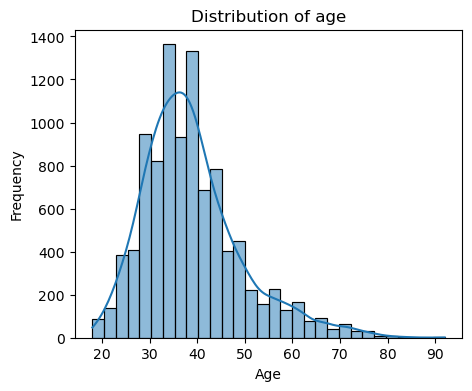

In [64]:
plt.figure(figsize=(5,4))
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Distribution of age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

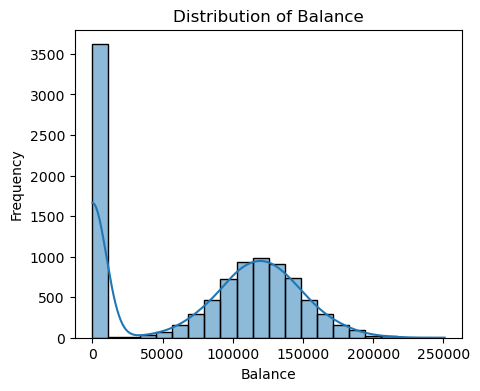

In [65]:
plt.figure(figsize=(5,4))
sns.histplot(df["Balance"],kde=True)
plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

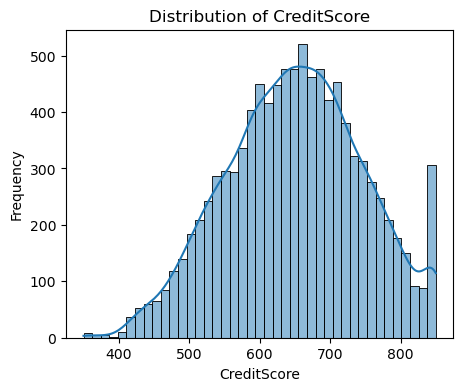

In [66]:
plt.figure(figsize=(5,4))
sns.histplot(df["CreditScore"],kde=True)
plt.title("Distribution of CreditScore")
plt.xlabel("CreditScore")
plt.ylabel("Frequency")
plt.show()

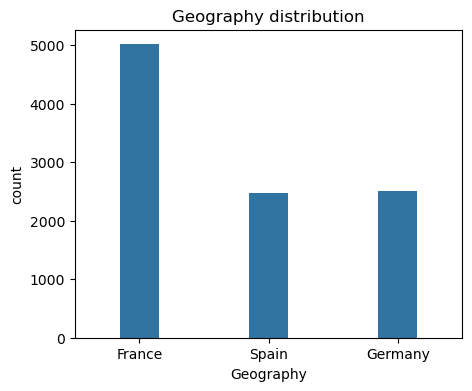

In [67]:
plt.figure(figsize=(5,4))
sns.countplot(x='Geography', data=df, width=0.3)
plt.title("Geography distribution")
plt.xlabel("Geography")
plt.ylabel("count")

plt.show()

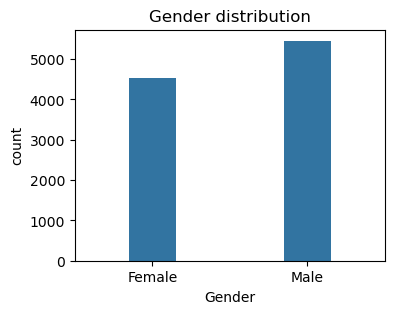

In [68]:
plt.figure(figsize=(4,3))
sns.countplot(x='Gender', data=df, width=0.3)

plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("count")

plt.show()


In [69]:
#BIVARIATE ANALYSIS  #axarr[row][col]-2D array,axarr[0][0] is top-left,...so on axarr[2][1] is bottom-right

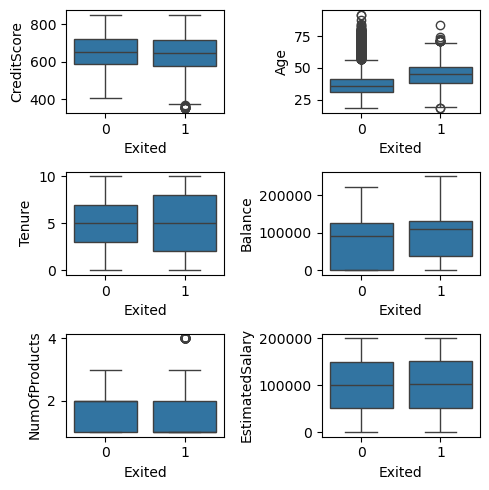

In [70]:
fig, axarr =plt.subplots(3,2, figsize=(5,5))

sns.boxplot(x='Exited', y= 'CreditScore', data=df , ax=axarr[0][0])
sns.boxplot(x='Exited', y= 'Age', data=df , ax=axarr[0][1])

sns.boxplot(x='Exited', y= 'Tenure', data=df , ax=axarr[1][0])
sns.boxplot(x='Exited', y= 'Balance', data=df , ax=axarr[1][1])

sns.boxplot(x='Exited', y= 'NumOfProducts', data=df , ax=axarr[2][0])
sns.boxplot(x='Exited', y= 'EstimatedSalary', data=df , ax=axarr[2][1])

plt.tight_layout()
plt.show()

In [71]:
# Each cell shows the Pearson correlation coefficient between two variables,
#ranging from -1 to +1.dark color represents most affected,
#its should be idealy like coolinearity with target variable shoudl be more and among each other should be less (HEAT MAP)

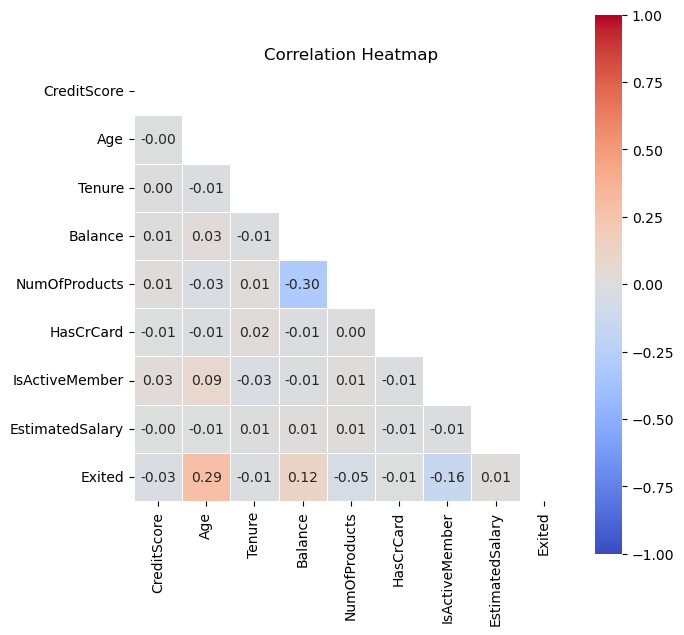

In [72]:
plt.figure(figsize=(7,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1, vmax=1,        # locks the color scale to the full correlation range
            square=True,           # makes cells square instead of rectangular
            linewidths=0.5,        # adds thin gridlines between cells
            mask=np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool)))  # shows only lower triangle (avoids redundancy))

plt.title('Correlation Heatmap')

plt.show()

In [73]:
#EDA completed 

In [74]:
#FEATURE ENGINEERING- we create new informative features from these 
#variables these features help in model performance and help in understanding the realtionship between data.

In [75]:
# 1 Balance to salary ratio

In [76]:
df["balance_to_salary"]=df["Balance"]/df["EstimatedSalary"]

In [77]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'balance_to_salary'],
      dtype='object')

In [78]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055


In [79]:
#2 Tenure by age 

In [80]:
df["Tenure_by_age"]=df["Balance"]/df["Age"]

In [81]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary,Tenure_by_age
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,2044.094146
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,3801.447619
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,2918.856279


In [82]:
# FEATURE ENCODING - To convert categorical values into numeric values because the data passed to the model is always numeric
#Two types-1)Lable encoding 
#         2)One hot encoding 

In [83]:
# label encoding - Gender

In [84]:
from sklearn.preprocessing import LabelEncoder

In [85]:
le=LabelEncoder()

In [86]:
df["Gender"]=le.fit_transform(df["Gender"])

In [87]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary,Tenure_by_age
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.000000
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,2044.094146
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,3801.447619
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.000000
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,2918.856279
5,645,Spain,1,44,8,113755.78,2,1,0,149756.71,1,0.759604,2585.358636
6,822,France,1,50,7,0.00,2,1,1,10062.80,0,0.000000,0.000000
7,376,Germany,0,29,4,115046.74,4,1,0,119346.88,1,0.963969,3967.128966
8,501,France,1,44,4,142051.07,2,0,1,74940.50,0,1.895518,3228.433409
9,684,France,1,27,2,134603.88,1,1,1,71725.73,0,1.876647,4985.328889


In [88]:
#One GHot encoding - Geography

In [89]:
df=pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [90]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary,Tenure_by_age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.000000,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,2044.094146,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,3801.447619,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.000000,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,2918.856279,False,True


In [91]:
# defining features and target variables

In [95]:
X=df.drop(["Exited"], axis=1)
y=df["Exited"]

In [52]:
# axis 0 operates over row 
# axis 1 operates over column

In [96]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,balance_to_salary,Tenure_by_age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0.000000,0.000000,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0.744677,2044.094146,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1.401375,3801.447619,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0.000000,0.000000,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,1.587055,2918.856279,False,True


In [53]:
# Splitting the dataset

In [48]:
from sklearn.model_selection import train_test_split

In [97]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=12)

In [98]:
X_train.shape

(8000, 13)

In [99]:
X_test.shape

(2000, 13)

In [100]:
y_train.shape

(8000,)

In [101]:
# Feature Scaling

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
sc=StandardScaler()

In [104]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,balance_to_salary,Tenure_by_age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0.000000,0.000000,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0.744677,2044.094146,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1.401375,3801.447619,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0.000000,0.000000,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,1.587055,2918.856279,False,True


In [105]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

# Model Training

1)Logistic Regression

2)KNN Classifier

3)Naive Bayes

4)Random Forest

5)XGB Classifier

6)ANN - Artificial Neural Network

# Logistic Regression

In [106]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [107]:
from sklearn.linear_model import LogisticRegression

In [108]:
lr_model = LogisticRegression()

In [109]:
lr_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [110]:
y_pred_lr = lr_model.predict(X_test)

In [111]:
lr_accuracy = accuracy_score(y_test,y_pred_lr)
lr_precision = precision_score(y_test,y_pred_lr)
lr_recall = recall_score(y_test,y_pred_lr)
lr_f1 = f1_score(y_test,y_pred_lr)

In [112]:
print("Accuracy: ", lr_accuracy)
print("Precision: ", lr_precision)
print("recall: ", lr_recall)
print("f1 Score: ", lr_f1)

Accuracy:  0.8095
Precision:  0.6870748299319728
recall:  0.231651376146789
f1 Score:  0.346483704974271


In [113]:
from sklearn.metrics import confusion_matrix

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

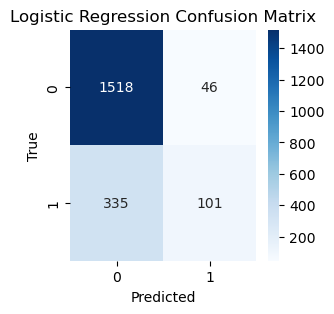

In [114]:
# fmt='d' - formats those numbers as integers(whole number)
# annot=true -displays the actual numbers inside each cell of the heatmap

cm=confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

In [115]:
cm

array([[1518,   46],
       [ 335,  101]])

In [116]:
model_results=[]

model_results.append({"Model":"Logistic Regression",
                       "Accuracy":lr_accuracy,
                       "Precision":lr_precision,
                       "Recall":lr_recall,
                       "F1 Score":lr_f1})

# KNN-Classifier

In [117]:
from sklearn.neighbors import KNeighborsClassifier

In [118]:
knn_model=KNeighborsClassifier()

In [119]:
knn_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [120]:
y_predict_knn=knn_model.predict(X_test)

In [121]:
knn_accuracy =accuracy_score(y_test, y_predict_knn)
knn_precision = precision_score(y_test, y_predict_knn)
knn_recall = recall_score(y_test, y_predict_knn)
knn_f1 = f1_score(y_test, y_predict_knn)

In [122]:
print("Accuracy: ",knn_accuracy)
print("Precision: ", knn_precision)
print("recall: ", knn_recall)
print("f1 Score: ", knn_f1)

Accuracy:  0.829
Precision:  0.7008547008547008
recall:  0.3761467889908257
f1 Score:  0.48955223880597015


Text(0.5, 1.0, 'KNN Classifier Confusion Matrix')

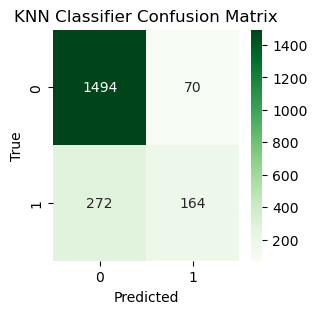

In [123]:
cm=confusion_matrix(y_test, y_predict_knn)

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Classifier Confusion Matrix")

In [124]:
cm

array([[1494,   70],
       [ 272,  164]])

In [125]:
model_results=[]

model_results.append({"Model":"KNN Classifier",
                       "Accuracy":knn_accuracy,
                       "Precision":knn_precision,
                       "Recall":knn_recall,
                       "F1 Score":knn_f1})

# Naive Bayes

In [126]:
from sklearn.naive_bayes import GaussianNB

In [127]:
nb_model=GaussianNB()

In [128]:
nb_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [129]:
y_predict_nb=nb_model.predict(X_test)

In [130]:
nb_accuracy = accuracy_score(y_test,y_predict_nb)
nb_precision = precision_score(y_test,y_predict_nb)
nb_recall = recall_score(y_test,y_predict_nb)
nb_f1 = f1_score(y_test,y_predict_nb)

In [131]:
print("Accuracy: ",nb_accuracy)
print("Precision: ", nb_precision)
print("recall: ", nb_recall)
print("f1 Score: ", nb_f1)

Accuracy:  0.789
Precision:  0.7692307692307693
recall:  0.045871559633027525
f1 Score:  0.08658008658008658


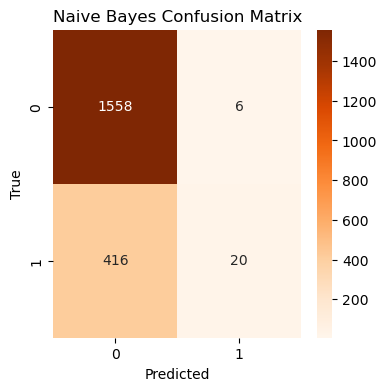

In [132]:
cm = confusion_matrix(y_test,y_predict_nb)

plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True ,cmap='Oranges',fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [133]:
model_results=[]

model_results.append({"Model":"Naive Bayes",
                       "Accuracy":nb_accuracy,
                       "Precision":nb_precision,
                       "Recall":nb_recall,
                       "F1 Score":nb_f1})

In [134]:
cm

array([[1558,    6],
       [ 416,   20]])

# Random Forest

In [135]:
from sklearn.ensemble import RandomForestClassifier

In [136]:
rf_model=RandomForestClassifier()

In [137]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
y_predict_rf=rf_model.predict(X_test)

In [139]:
rf_accuracy=accuracy_score(y_test, y_predict_rf)
rf_precision= precision_score(y_test, y_predict_rf)
rf_recall = recall_score(y_test, y_predict_rf)
rf_f1 = f1_score(y_test, y_predict_rf)

print("accuracy:",rf_accuracy)
print("precision:",rf_precision)
print("recall:",rf_recall)
print("F1 score:",rf_f1)


accuracy: 0.8675
precision: 0.8326848249027238
recall: 0.4908256880733945
F1 score: 0.6176046176046176


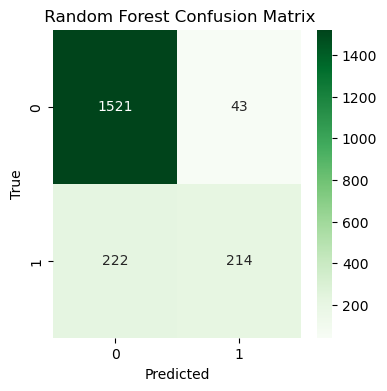

In [140]:
cm = confusion_matrix(y_test,y_predict_rf)

plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True ,cmap='Greens',fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(" Random Forest Confusion Matrix")
plt.show()

In [141]:
model_results.append({"Model":"Random Forest",
                       "Accuracy":rf_accuracy,
                       "Precision":rf_precision,
                       "Recall":rf_recall,
                       "F1 Score":rf_f1})

In [142]:
cm

array([[1521,   43],
       [ 222,  214]])

 # XG BOOST

In [143]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [144]:
from xgboost import XGBClassifier
print("Success!")

Success!


In [145]:
model_xgb= XGBClassifier()

In [146]:
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [147]:
y_predict_xgb= model_xgb.predict(X_test)

In [148]:
xgb_accuracy=accuracy_score(y_test, y_predict_xgb)
xgb_precision= precision_score(y_test, y_predict_xgb)
xgb_recall = recall_score(y_test, y_predict_xgb)
xgb_f1 = f1_score(y_test, y_predict_xgb)

print("accuracy:",xgb_accuracy)
print("precision:",xgb_precision)
print("recall:",xgb_recall)
print("F1 score:",xgb_f1)


accuracy: 0.854
precision: 0.7416107382550335
recall: 0.5068807339449541
F1 score: 0.6021798365122616


In [149]:
model_results.append({"Model":"XG Boost Classifier",
                       "Accuracy":xgb_accuracy,
                       "Precision":xgb_precision,
                       "Recall":xgb_recall,
                       "F1 Score":xgb_f1})

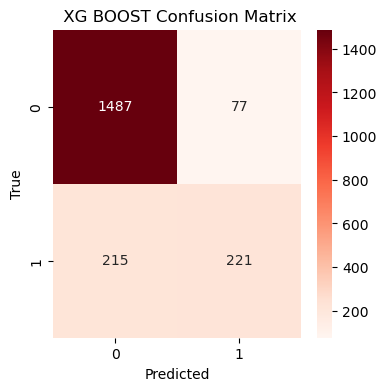

In [150]:
cm = confusion_matrix(y_test,y_predict_xgb)

plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True ,cmap='Reds',fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(" XG BOOST Confusion Matrix")
plt.show()

In [151]:
cm

array([[1487,   77],
       [ 215,  221]])

# ANN- Artificial Neural network

In [152]:
import tensorflow as tf
from tensorflow import keras

In [153]:
model=keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dense(6, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [154]:
#Complie the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [155]:
# Use the Adam optimizer to adjust weights during training,
# measure mistakes using binary cross-entropy (since this is a yes/no prediction problem),
# and track accuracy along the way so I can see how well it's learning.

In [156]:
history=model.fit(X_train, y_train,
                  epochs=100,
                  batch_size=32,
                  validation_split=0.2
                  )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6941 - loss: 0.6082 - val_accuracy: 0.8019 - val_loss: 0.5088
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4740 - val_accuracy: 0.8087 - val_loss: 0.4544
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 0.4372 - val_accuracy: 0.8169 - val_loss: 0.4344
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8178 - loss: 0.4219 - val_accuracy: 0.8138 - val_loss: 0.4254
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8233 - loss: 0.4128 - val_accuracy: 0.8200 - val_loss: 0.4177
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8289 - loss: 0.4048 - val_accuracy: 0.8231 - val_loss: 0.4113
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8336 - loss: 0.3975 - val_accuracy: 0.8306 - val_loss: 0.4044
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8391 - loss: 0.3890 - val_accu

In [157]:
y_pred_ann=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


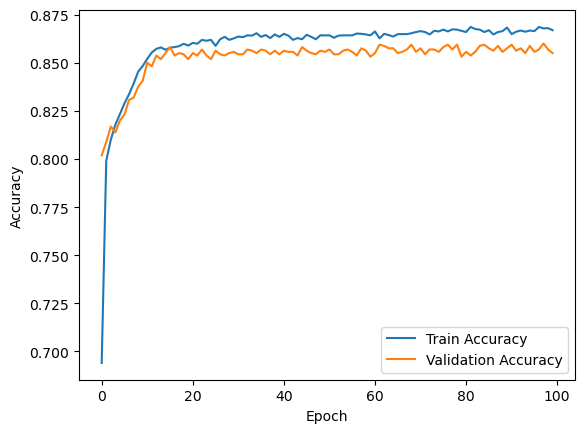

In [158]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [159]:
y_pred_ann=(y_pred_ann>0.5)

In [160]:
ann_accuracy=accuracy_score(y_test, y_pred_ann)
ann_precision= precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print("accuracy:",ann_accuracy)
print("precision:",ann_precision)
print("recall:",ann_recall)
print("F1 score:",ann_f1)

accuracy: 0.8575
precision: 0.8032128514056225
recall: 0.45871559633027525
F1 score: 0.583941605839416


In [161]:
model_results.append({"Model":"ANN Model",
                       "Accuracy":ann_accuracy,
                       "Precision":ann_precision,
                       "Recall":ann_recall,
                       "F1 Score":ann_f1})

# Conclusion

In [162]:
result_df= pd.DataFrame(model_results)

In [163]:
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.7890,0.769231,0.045872,0.086580
1,Random Forest,0.8675,0.832685,0.490826,0.617605
2,XG Boost Classifier,0.8540,0.741611,0.506881,0.602180
3,ANN Model,0.8575,0.803213,0.458716,0.583942


In [164]:
#extra for my understanding as i got only 2 models above 
model_results=[]

model_results.append({"Model":"Logistic Regression",
                       "Accuracy":lr_accuracy,
                       "Precision":lr_precision,
                       "Recall":lr_recall,
                       "F1 Score":lr_f1})

model_results.append({"Model":"KNN Classifier",
                       "Accuracy":knn_accuracy,
                       "Precision":knn_precision,
                       "Recall":knn_recall,
                       "F1 Score":knn_f1})

model_results.append({"Model":"Naive Bayes",
                       "Accuracy":nb_accuracy,
                       "Precision":nb_precision,
                       "Recall":nb_recall,
                       "F1 Score":nb_f1})

model_results.append({"Model":"Random Forest",
                       "Accuracy":rf_accuracy,
                       "Precision":rf_precision,
                       "Recall":rf_recall,
                       "F1 Score":rf_f1})

model_results.append({"Model":"XG Boost Classifier",
                       "Accuracy":xgb_accuracy,
                       "Precision":xgb_precision,
                       "Recall":xgb_recall,
                       "F1 Score":xgb_f1})

model_results.append({"Model":"ANN Model",
                       "Accuracy":ann_accuracy,
                       "Precision":ann_precision,
                       "Recall":ann_recall,
                       "F1 Score":ann_f1})


In [165]:
result_df = pd.DataFrame(model_results)

In [166]:
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8095,0.687075,0.231651,0.346484
1,KNN Classifier,0.8290,0.700855,0.376147,0.489552
2,Naive Bayes,0.7890,0.769231,0.045872,0.086580
3,Random Forest,0.8675,0.832685,0.490826,0.617605
4,XG Boost Classifier,0.8540,0.741611,0.506881,0.602180
5,ANN Model,0.8575,0.803213,0.458716,0.583942


In [167]:
# Save the trained ANN model
model.save('churn_ann_model.h5')

# Save the scaler (needed to preprocess new inputs the same way)
import pickle
pickle.dump(sc, open('scaler.pkl', 'wb'))

In [168]:
import os
print(os.path.exists('churn_ann_model.h5'))  # should print True
print(os.path.exists('scaler.pkl'))          # should print True

True
True


In [169]:
X.columns.tolist()

['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'balance_to_salary',
 'Tenure_by_age',
 'Geography_Germany',
 'Geography_Spain']

In [170]:
import os
print(os.getcwd())

C:\Users\vidya
